# Image Gradient and Its Relationship to Edges

One of the most fundamental concepts in image processing is the **image gradient**. Nearly all classical **edge detection algorithms** are built upon this concept.

The basic idea is very simple:

> **Wherever the image intensity changes rapidly, there is likely an edge.**

Therefore, if we can measure how quickly the pixel intensity changes, we can identify the locations of edges.

---

# What Is the Image Gradient?

The **image gradient** measures the **rate of change in image intensity**.

If two neighboring pixels have nearly the same intensity, the change is very small, and the gradient has a **low magnitude**.

On the other hand, if there is a large difference in intensity between neighboring pixels, the gradient becomes **large**, indicating that an edge is likely present.

In simple terms:

- **Small intensity change** → **Small gradient**
- **Large intensity change** → **Large gradient**
- **Abrupt intensity change** → **Likely an edge**

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
img = cv2.cvtColor(cv2.imread('images.jpg'),cv2.COLOR_BGR2RGB)

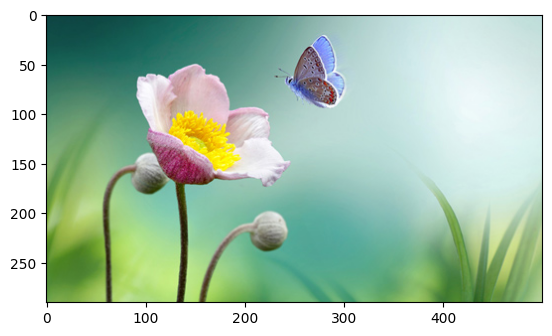

In [5]:
plt.imshow(img)
plt.show()

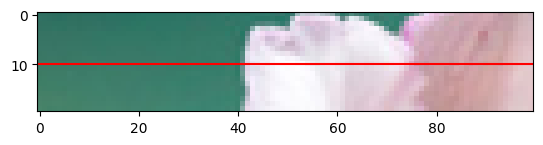

In [9]:
imgc = img[60:80, 50:150,: ]
plt.imshow(imgc)
plt.axhline(10,color='red')
plt.show()

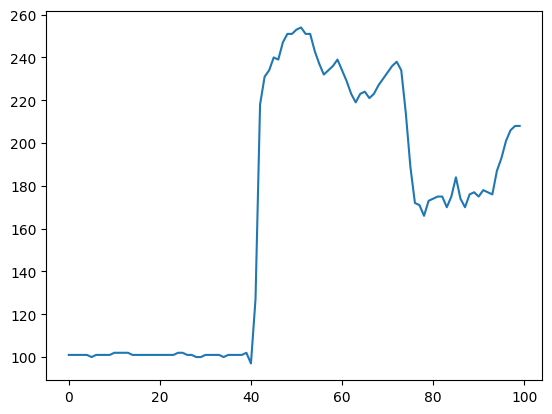

In [11]:
imgc_gray = cv2.cvtColor(imgc,cv2.COLOR_RGB2GRAY)
plt.plot(imgc_gray[10,:])
plt.show()

In [12]:
np.gradient(imgc_gray[10,:])

array([  0. ,   0. ,   0. ,   0. ,  -0.5,   0. ,   0.5,   0. ,   0. ,
         0.5,   0.5,   0. ,   0. ,  -0.5,  -0.5,   0. ,   0. ,   0. ,
         0. ,   0. ,   0. ,   0. ,   0. ,   0.5,   0.5,  -0.5,  -0.5,
        -0.5,  -0.5,   0.5,   0.5,   0. ,   0. ,  -0.5,   0. ,   0.5,
         0. ,   0. ,   0.5,  -2. ,  12.5,  60.5,  52. ,   8. ,   4.5,
         2.5,   3.5,   6. ,   2. ,   1. ,   1.5,  -1. ,  -1.5,  -4. ,
        -7. ,  -5.5,  -1.5,   2. ,   2.5,  -1. ,  -5. ,  -5.5,  -5. ,
         0. ,   2.5,  -1. ,  -0.5,   3. ,   3.5,   3. ,   3. ,   2.5,
        -1. , -12. , -22.5, -21. ,  -9. ,  -3. ,   1. ,   4. ,   1. ,
         0.5,  -2.5,   0. ,   7. ,  -0.5,  -7. ,   1. ,   3.5,  -0.5,
         0.5,   1. ,  -1. ,   5. ,   8.5,   7. ,   6.5,   3.5,   1. ,
         0. ])

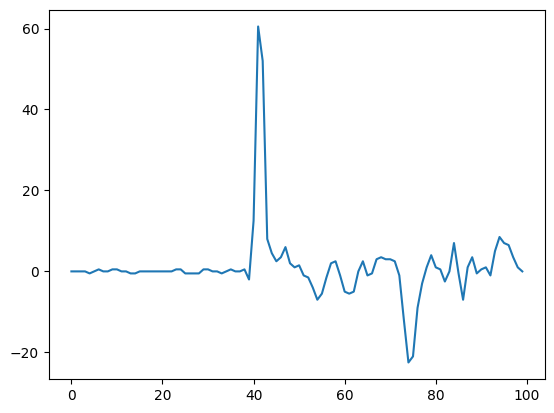

In [13]:
plt.plot(np.gradient(imgc_gray[10,:]))
plt.show()

# Comparing the Image, Intensity Profile, and Gradient

To better understand the concept of the **image gradient**, it is common to visualize three representations side by side:

1. **Original Image**
2. **Intensity Profile**
3. **Gradient Profile**

By observing these three representations together, it becomes clear that **wherever the image intensity changes abruptly, the gradient produces a large peak**. These peaks correspond to the locations of **image edges**.

In other words:

- **Original Image** → Shows the visual content.
- **Intensity Profile** → Illustrates how pixel intensity changes along a selected line.
- **Gradient Profile** → Measures the rate of intensity change and highlights edge locations.

Therefore, **large peaks in the gradient profile indicate strong edges**, while flat regions with little or no intensity variation produce gradient values close to zero.

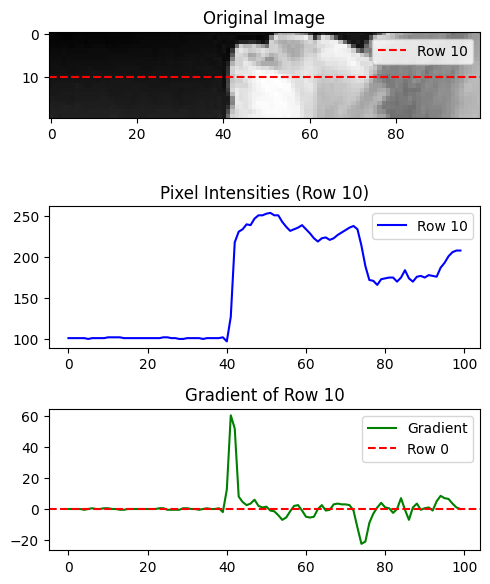

In [17]:
plt.figure(figsize=(5, 6))

plt.subplot(3, 1, 1)
plt.title("Original Image")
plt.imshow(imgc_gray, cmap='gray')
plt.axhline(10, color='red', linestyle='--', label='Row 10')
plt.legend()

plt.subplot(3, 1, 2)
plt.title("Pixel Intensities (Row 10)")
plt.plot(imgc_gray[10,:], label='Row 10', color='blue')
plt.legend()

plt.subplot(3, 1, 3)
plt.title("Gradient of Row 10")
plt.plot(np.gradient(imgc_gray[10,:]), label='Gradient', color='green')
plt.axhline(0, color='red', linestyle='--', label='Row 0')
plt.legend()

plt.tight_layout()
plt.show()

# Effect of Blur on the Image Gradient

One of the most important experiments in image processing is comparing the **image gradient** before and after applying a **blur** filter.

When an image is smoothed using a **Mean Filter** or a **Gaussian Filter**:

- Intensity transitions become smoother.
- The differences between neighboring pixel intensities decrease.
- Edges become weaker and less distinct.

As a result, the **gradient magnitude** also decreases.

In other words, **blurring reduces the rate of intensity change**, causing the gradient peaks at edge locations to become lower and broader.

Therefore, although blur effectively reduces noise, it also weakens edge information, making edge detection more challenging.

In [19]:
imgc_blur = cv2.blur(imgc,(5,5))
imgc_blur_gray = cv2.cvtColor(imgc_blur,cv2.COLOR_RGB2GRAY)

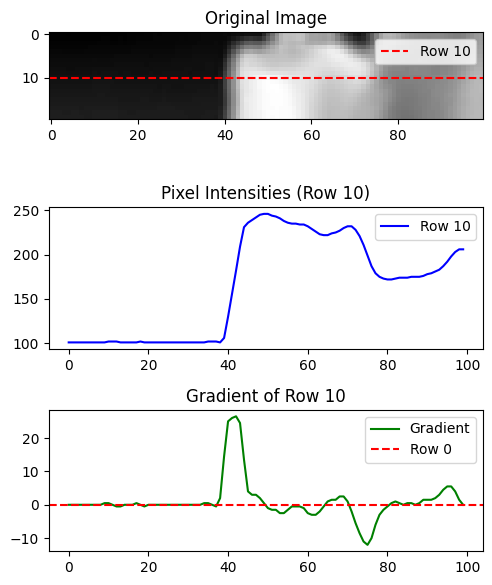

In [20]:
plt.figure(figsize=(5, 6))

plt.subplot(3, 1, 1)
plt.title("Original Image")
plt.imshow(imgc_blur_gray, cmap='gray')
plt.axhline(10, color='red', linestyle='--', label='Row 10')
plt.legend()

plt.subplot(3, 1, 2)
plt.title("Pixel Intensities (Row 10)")
plt.plot(imgc_blur_gray[10,:], label='Row 10', color='blue')
plt.legend()

plt.subplot(3, 1, 3)
plt.title("Gradient of Row 10")
plt.plot(np.gradient(imgc_blur_gray[10,:]), label='Gradient', color='green')
plt.axhline(0, color='red', linestyle='--', label='Row 0')
plt.legend()

plt.tight_layout()
plt.show()

# Second derivative

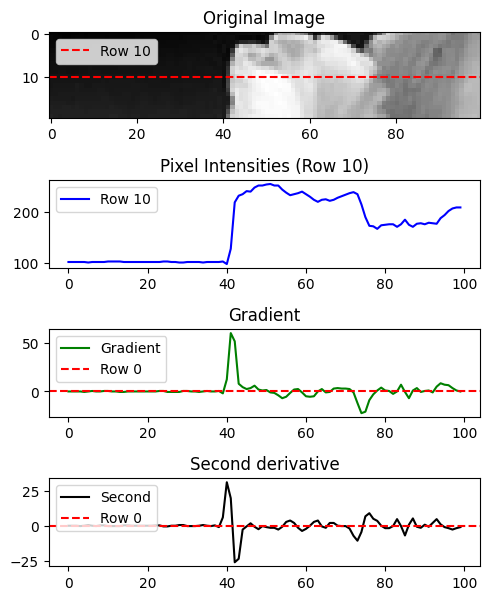

In [15]:
plt.figure(figsize=(5, 6))

plt.subplot(4, 1, 1)
plt.title("Original Image")
plt.imshow(imgc_gray, cmap='gray')
plt.axhline(10, color='red', linestyle='--', label='Row 10')
plt.legend(loc="upper left")

plt.subplot(4, 1, 2)
plt.title("Pixel Intensities (Row 10)")
plt.plot(imgc_gray[10,:], label='Row 10', color='blue')
plt.legend(loc="upper left")

gradient = np.gradient(imgc_gray[10,:])

plt.subplot(4, 1, 3)
plt.title("Gradient")
plt.plot(gradient, label='Gradient', color='green')
plt.axhline(0, color='red', linestyle='--', label='Row 0')
plt.legend(loc="upper left")

plt.subplot(4, 1, 4)
plt.title("Second derivative")
plt.plot(np.gradient(gradient), label='Second', color='black')
plt.axhline(0, color='red', linestyle='--', label='Row 0')
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()